# Model Implementation

## Path fixes -_-

In [4]:
import os 
import sys
from pathlib import Path

user = os.path.expanduser('~') 
root_dir = '/Identifying_Malicious_URLs/'

full_path = os.path.join(os.curdir,user+root_dir)



%cd $full_path

/home/faizan/Identifying_Malicious_URLs


## Libraries

In [5]:
# from keras.utils import text_dataset_from_directory


import numpy as np
import pandas as pd
import keras
from keras import layers
from keras import models
from src.encoding.unicode_encoding import EncodingwithPadding
from sklearn.model_selection import train_test_split
from keras import metrics
import matplotlib.pyplot as plt 



## Model 

In [3]:
# def model(vgg16):
#     conv_base = models.Sequential()
#     conv_base.add(vgg16)
#     conv_base.add(layers.Flatten())
#     conv_base.add(layers.Dense(256,activation='relu'))
#     conv_base.add(layers.Dense(4,activation='softmax'))
#     return conv_base

model = models.Sequential([

    layers.Input(shape=(24, 24, 1)),


    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),


    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),


    layers.Flatten(),


    layers.Dense(128, activation='relu'),

    
    layers.Dense(4, activation='softmax')
])

W0000 00:00:1776064858.987838   15841 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Data Preparing 

In [4]:
df = pd.read_csv(full_path+'src/Dataset/malicious_phish.csv')

In [5]:
encoded_data = EncodingwithPadding()
X = np.array(df['url'].apply(EncodingwithPadding.encode_eachChar).to_list(),dtype=np.int32)
y = df['type']



### LE target

In [6]:
le = {
    "phishing":0,
    "benign":1,
    "defacement":2,
    "malware":3
}
y = y.map(le)


In [7]:
x_train,x_temp,y_train,y_temp =train_test_split(X,y, test_size=0.3,random_state=42,stratify=y) #train test split according to need 

x_val, x_test, y_val, y_test = train_test_split(x_temp,y_temp,test_size=0.5 ,random_state=42,stratify=y_temp)

### Typing checking 

In [8]:
print(f'Xtrain Shape: {x_train.shape} , Xtrain dtype: {x_train.dtype}')
print(f'Xtest Shape: {x_test.shape} , Xtest dtype: {x_test.dtype}')
print(f'Xval Shape: {x_val.shape} , Xval dtype: {x_val.dtype}')
print(f'ytrain Shape: {y_train.shape} , ytriain dtype: {y_train.dtype}')
print(f'Xval Shape: {y_test.shape} , y_test dtype: {y_test.dtype}')
print(f'Xval Shape: {y_val.shape} , y_val dtype: {y_val.dtype}')


Xtrain Shape: (455833, 24, 24) , Xtrain dtype: int32
Xtest Shape: (97679, 24, 24) , Xtest dtype: int32
Xval Shape: (97679, 24, 24) , Xval dtype: int32
ytrain Shape: (455833,) , ytriain dtype: int64
Xval Shape: (97679,) , y_test dtype: int64
Xval Shape: (97679,) , y_val dtype: int64


In [9]:
x_train[0]

array([[105, 109, 100,  98,  46, 105, 116,  47, 110,  97, 109, 101,  47,
        110, 109,  48,  52,  52,  54,  51,  49,  52,  47,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0

## Model Training  

In [10]:

print(model.summary())



model.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

history = model.fit(x_train,y_train,
                epochs=10,
                batch_size=128,
                validation_data=(x_val,y_val))

model.save_weights('savedModel/model_weights.weights.h5')
model.save('savedModel/malicious_url_checker_model.keras')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,772 (940.52 KB)

 Trainable params: 240,772 (940.52 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
3562/3562 ━━━━━━━━━━━━━━━━━━━━ 71s 20ms/step - accuracy: 0.8878 - loss: 0.3516 - val_accuracy: 0.9238 - val_loss: 0.2306
Epoch 2/10
3562/3562 ━━━━━━━━━━━━━━━━━━━━ 75s 21ms/step - accuracy: 0.9292 - loss: 0.2169 - val_accuracy: 0.9351 - val_loss: 0.1956
Epoch 3/10
3562/3562 ━━━━━━━━━━━━━━━━━━━━ 81s 23ms/step - accuracy: 0.9396 - loss: 0.1828 - val_accuracy: 0.9426 - val_loss: 0.1790
Epoch 4/10
3562/3562 ━━━━━━━━━━━━━━━━━━━━ 75s 21ms/step - accuracy: 0.9456 - loss: 0.1666 - val_accuracy: 0.9393 - val_loss: 0.1870
Epoch 5/10
3562/3562 ━━━━━━━━━━━━━━━━━━━━ 74s 21ms/step - accuracy: 0.9498 - loss: 0.1592 - val_accuracy: 0.9458 - val_loss: 0.1628
Epoch 6/10
3562/3562 ━━━━━━━━━━━━━━━━━━━━ 74s 21ms/step - accuracy: 0.9528 - loss: 0.1411 - val_accuracy: 0.9511 - val_loss: 0.1526
Epoch 7/10
3562/3562 ━━━━━━━━━━━━━━━━━━━━ 74s 21ms/step - accuracy: 0.9545 - loss: 0.1654 - val_accuracy: 0.9516 - val_loss: 0.1480
Epoch 8/10
3562/3562 ━━━━━━━━━━━━━━━━━━━━ 74s 21ms/step - accuracy: 0.9

## Visulizing the Model Performance

764/764 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9551 - loss: 0.1436
test loss, test acc: [0.14357595145702362, 0.9551387429237366]


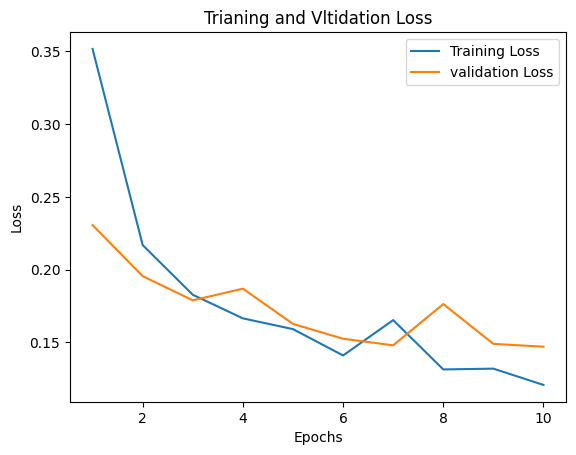

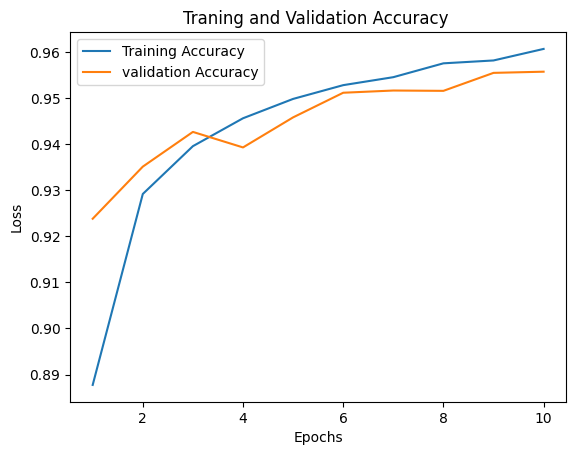

In [11]:
history_dict = history.history

acc = history_dict['accuracy']
train_loss = history_dict['loss']
val_loss = history_dict['val_loss']

results = model.evaluate(x_test, y_test, batch_size=128)
print("test loss, test acc:", results)

epochs = range(1,len(acc)+1)

plt.plot(epochs,train_loss,label='Training Loss')
plt.plot(epochs,val_loss,label='validation Loss')
plt.title('Trianing and Vltidation Loss')
plt.xlabel("Epochs")
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()

val_acc = history_dict['val_accuracy']

plt.plot(epochs,acc,label='Training Accuracy')
plt.plot(epochs,val_acc,label="validation Accuracy")
plt.title('Traning and Validation Accuracy ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

## Testing 


In [ ]:
test_data = [
    {"url": "alpha-lab-preview.example/test-login-2026", "type": "phishing"},
    {"url": "beta-secure-check.example/reset/session-a19", "type": "phishing"},
    {"url": "gamma-portal-review.example/user/verify-now", "type": "phishing"},
    {"url": "delta-cloud-gateway.example/files/archive-91", "type": "malware"},
    {"url": "epsilon-billing-center.example/invoice/open-443", "type": "phishing"},
    {"url": "zeta-auth-node.example/account/recovery-step2", "type": "malware"},
    {"url": "theta-support-desk.example/ticket/update-77", "type": "benign"},
    {"url": "kappa-market-watch.example/deals/today-special", "type": "benign"},
    {"url": "lambda-mail-hub.example/message/confirm-id8", "type": "phishing"},
    {"url": "mu-data-vault.example/share/report-q4", "type": "benign"},
    {"url": "nu-edge-router.example/device/login-panel", "type": "malware"},
    {"url": "xi-member-access.example/profile/security-check", "type": "phishing"},
    {"url": "omicron-payments.example/checkout/retry-order", "type": "benign"},
    {"url": "pi-client-space.example/documents/sign-here", "type": "defacement"},
    {"url": "rho-service-center.example/helpdesk/reopen-case", "type": "benign"},
    {"url": "sigma-cdn-cache.example/assets/img/load", "type": "benign"},
    {"url": "tau-system-health.example/status/live-monitor", "type": "benign"},
    {"url": "upsilon-web-console.example/admin/review-alert", "type": "defacement"},
    {"url": "phi-notice-board.example/post/read-thread", "type": "benign"},
    {"url": "chi-test-domain.example/path/mock-endpoint", "type": "defacement"},
]


# eval_data = EncodingwithPadding.encode_eachChar(test_data['url'])
# eval_label = test_data['type']
urls = []
labels = []
def le(i):
    
    if i == "phishing":
        return 0
    elif i == "benign":
        return 1
    elif i == "defacement":
        return 2
    elif i == "malware":
        return 3



for i in test_data:
    urls.append(EncodingwithPadding.encode_eachChar(i['url']))
    labels.append(le(i['type']))



In [23]:
def find_label(pred):
    lable = ["phishing","benign","defacement","malware"]
    idx = np.argmax(pred)
    pred = lable[idx]
    pred = le(pred)
    return pred


In [38]:
test_model = models.load_model('savedModel/malicious_url_checker_model.keras')
X = np.array(urls)
y_pred = test_model(X)
classes = ["phishing","benign","defacement","malware"]
predictions = []

for i in range(y_pred.shape[0]):
    predictions.append(find_label(y_pred[i]))

predictions = np.array(predictions,dtype=np.int32)
Cmat = classification_report(labels,predictions,labels=[0,1,2,3],target_names=["phishing","benign","defacement","malware"],zero_division=0)


In [39]:
print(Cmat)

              precision    recall  f1-score   support

    phishing       0.00      0.00      0.00         6
      benign       0.40      1.00      0.57         8
  defacement       0.00      0.00      0.00         3
     malware       0.00      0.00      0.00         3

    accuracy                           0.40        20
   macro avg       0.10      0.25      0.14        20
weighted avg       0.16      0.40      0.23        20

